# SleepFM LOO-CL 분석 워크스루

이 노트북은 지금까지 진행한 `LOO-CL latent-space audit`를 단계별로 다시 읽고 이해하기 위한 안내서다.

이 노트북에서 보는 순서는 다음과 같다.

1. SleepFM 구현에서 LOO-CL이 실제로 어떻게 계산되는지 확인
2. `5분 aggregated embedding`으로 geometry metric이 어떻게 만들어졌는지 확인
3. 전체 SHHS에서 나온 geometry 요약 통계를 읽기
4. downstream disease prediction 결과와 geometry를 join한 결과를 읽기
5. scatter / constellation / heatmap figure를 해석하기

중요한 점은, 이 노트북은 **설명을 위한 노트북**이라는 것이다. 계산이 이미 끝난 아티팩트를 우선 읽고, 필요하면 마지막에 재실행 명령을 확인하면 된다.

In [1]:
from pathlib import Path
import json
import pickle

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

SLEEPFM_CLINICAL = ROOT.parent / 'sleepfm-clinical'

GEOM_DIR = ROOT / 'artifacts' / 'audit' / 'loo_geometry_model_base_paperexact_shhs'
DIAG_DIR = GEOM_DIR / 'diagnosis_6y'
EVAL_DIR = ROOT / 'artifacts' / 'embeddings' / 'model_base_paperexact' / 'DiagnosisFinetuneFullLSTMCOXPHWithDemo_shhs_shhs_6cvd_paperexact_3291_496_2000_demo_labels_BAS_RESP_EKG_EMG__ep_5_bs_8' / 'shhs_downstream_paperlike_3291_496_2000' / 'test'
LABELS_DIR = ROOT / 'artifacts' / 'labels' / 'shhs_6cvd_paperexact_3291_496_2000'

def show_file_lines(path: Path, start: int, end: int):
    lines = path.read_text(encoding='utf-8', errors='ignore').splitlines()
    snippet = []
    for idx in range(start, end + 1):
        snippet.append(f'{idx:>4}: {lines[idx - 1]}')
    print('\n'.join(snippet))

def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

def load_pickle(path: Path):
    with open(path, 'rb') as handle:
        return pickle.load(handle)

ROOT, GEOM_DIR.exists(), DIAG_DIR.exists(), EVAL_DIR.exists(), LABELS_DIR.exists()

(WindowsPath('C:/Projects/aiot/sleepfm-repro'), True, True, True, True)

## 1. 구현 audit: SleepFM에서 LOO-CL이 실제로 어떻게 계산되는가

먼저 확인해야 하는 질문은 다음이다.

- modality embedding을 평균 전에 normalize 하는가?
- leave-one-out mean을 어떻게 만드는가?
- `5분 aggregated`와 `5초 sequence` embedding은 각각 어디서 저장되는가?
- geometry audit 스크립트는 어떤 입력을 읽는가?

아래 코드 셀은 이 질문에 해당하는 실제 구현 줄을 그대로 보여준다.

In [2]:
pretrain_py = SLEEPFM_CLINICAL / 'sleepfm' / 'pipeline' / 'pretrain.py'
generate_py = SLEEPFM_CLINICAL / 'sleepfm' / 'pipeline' / 'generate_embeddings.py'
models_py = SLEEPFM_CLINICAL / 'sleepfm' / 'models' / 'models.py'
audit_py = ROOT / 'scripts' / 'analyze_loo_geometry.py'

print('pretrain.py 핵심 줄')
show_file_lines(pretrain_py, 42, 92)

print('\n' + '=' * 100 + '\n')
print('generate_embeddings.py 핵심 줄')
show_file_lines(generate_py, 124, 175)

print('\n' + '=' * 100 + '\n')
print('models.py 핵심 줄')
show_file_lines(models_py, 129, 152)

print('\n' + '=' * 100 + '\n')
print('analyze_loo_geometry.py 핵심 줄')
show_file_lines(audit_py, 70, 122)

pretrain.py 핵심 줄
  42:         model(ekg, mask_ekg),
  43:         model(emg, mask_emg),
  44:     ]
  45: 
  46:     emb = [e[0] for e in emb]
  47: 
  48:     for i in range(num_modalities):
  49:         emb[i] = torch.nn.functional.normalize(emb[i])
  50: 
  51:     if mode == "pairwise":
  52:         loss = 0.
  53:         pairwise_loss = np.zeros((num_modalities, num_modalities), dtype=float)
  54:         correct = np.zeros((num_modalities, num_modalities), dtype=int)
  55:         pairs = np.zeros((num_modalities, num_modalities), dtype=int)
  56: 
  57:         for i in range(num_modalities ):
  58:             for j in range(i + 1, num_modalities):
  59: 
  60:                 logits = torch.matmul(emb[i], emb[j].transpose(0, 1)) * torch.exp(temperature)
  61:                 labels = torch.arange(logits.shape[0], device=device)
  62:     
  63:                 l = torch.nn.functional.cross_entropy(logits, labels, reduction="sum")
  64:                 loss += l
  65:      

### 구현 audit 해석

위 코드를 읽으면 다음을 확인할 수 있다.

- `pretrain.py`에서 각 modality의 pooled embedding은 먼저 `torch.nn.functional.normalize`로 L2 normalize 된다.
- 그 다음 query modality를 뺀 나머지의 평균 `other_emb`를 만든 뒤 양방향 cross-entropy를 계산한다.
- `models.py`의 `SetTransformer.forward()`는 `(x, embedding)`을 반환하는데, 여기서 `x`는 `temporal_pooling` 이후의 5분 pooled embedding이고 `embedding`은 5초 sequence embedding이다.
- `generate_embeddings.py`는 `e[0]`를 `5분 aggregated`, `e[1]`를 `5초 sequence`로 각각 HDF5에 저장한다.
- `analyze_loo_geometry.py`는 이 `5분 aggregated` HDF5를 읽어서 `consensus norm`, `alignment`, `jackknife instability`를 계산한다.

즉, 우리가 현재 보고 있는 분석은 네 메모에서 적은 `pretraining-level latent audit`과 정확히 같은 층위의 분석이다.

## 2. 전체 SHHS geometry 결과 읽기

이제 실제로 계산된 전체 SHHS geometry 요약을 읽는다. 이 결과는 `paperexact` embedding 5,787명, 582,153개 5분 window 기준이다.

In [3]:
geom_summary = load_json(GEOM_DIR / 'summary.json')
pd.Series(geom_summary)

base                                  C:\Projects\aiot\sleepfm-repro\artifacts\embed...
modalities                                                        [BAS, RESP, EKG, EMG]
n_subjects                                                                         5787
n_windows_total                                                                  582153
jackknife_scale                                                                    half
alignment_mean_dataset                                                         0.626525
consensus_norm_mean_dataset                                                    0.797188
loo_mean_norm_mean_dataset                                                     0.822051
jackknife_instability_mean_dataset                                             0.078905
modality_alignment_dataset            {'BAS': 0.5695549995858956, 'RESP': 0.62973949...
subject_csv                           C:\Projects\aiot\sleepfm-repro\artifacts\audit...
window_csv                      

In [4]:
subject_df = pd.read_csv(GEOM_DIR / 'subject_metrics.csv')
window_df = pd.read_csv(GEOM_DIR / 'window_metrics.csv')

display(Markdown('### Subject-level 분포'))
display(subject_df[['consensus_norm_mean', 'loo_mean_norm_mean', 'alignment_mean', 'jackknife_instability_mean']].describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]).T)

display(Markdown('### 가장 불안정한 subject 10개'))
display(subject_df.sort_values('jackknife_instability_mean', ascending=False)[['subject', 'consensus_norm_mean', 'alignment_mean', 'jackknife_instability_mean']].head(10))

display(Markdown('### Window-level 분포'))
display(window_df[['consensus_norm', 'loo_mean_norm_mean', 'alignment_mean', 'jackknife_instability']].describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]).T)

### Subject-level 분포

,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
consensus_norm_mean,5787.0,0.797204,0.014475,0.726457,0.758229,0.771486,0.777763,0.799039,0.814101,0.817983,0.823866,0.847347
loo_mean_norm_mean,5787.0,0.822065,0.012476,0.761539,0.788664,0.799963,0.805336,0.823615,0.836652,0.840043,0.845109,0.865524
alignment_mean,5787.0,0.626557,0.027897,0.487769,0.550471,0.576756,0.589145,0.630123,0.658993,0.666361,0.677541,0.721942
jackknife_instability_mean,5787.0,0.078899,0.006726,0.057036,0.066918,0.069453,0.071183,0.077948,0.087994,0.090983,0.097705,0.113515


### 가장 불안정한 subject 10개

,subject,consensus_norm_mean,alignment_mean,jackknife_instability_mean
1537,shhs1-201542,0.726457,0.487769,0.113515
4909,shhs1-204927,0.729234,0.493087,0.111853
3336,shhs1-203347,0.730927,0.497353,0.111139
5181,shhs1-205199,0.731655,0.497865,0.109865
2353,shhs1-202363,0.736052,0.507100,0.108432
1337,shhs1-201342,0.740244,0.514700,0.106289
3362,shhs1-203373,0.741742,0.517505,0.105807
2562,shhs1-202572,0.740054,0.514879,0.105765
4141,shhs1-204153,0.742650,0.519673,0.105673
4668,shhs1-204681,0.742995,0.521350,0.105353


### Window-level 분포

,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
consensus_norm,582153.0,0.797188,0.023962,0.678110,0.736965,0.757507,0.767064,0.797445,0.827322,0.835756,0.851019,0.920848
loo_mean_norm_mean,582153.0,0.822051,0.020686,0.720662,0.770363,0.787886,0.796061,0.822219,0.848111,0.855442,0.868729,0.929914
alignment_mean,582153.0,0.626525,0.045981,0.390714,0.509277,0.549945,0.568648,0.627333,0.684052,0.699950,0.728660,0.857862
jackknife_instability,582153.0,0.078905,0.010934,0.027567,0.055399,0.061810,0.065385,0.078514,0.092766,0.097422,0.107711,0.138999


### geometry 결과 해석

여기서 먼저 봐야 할 포인트는 다음이다.

- dataset 평균은 `alignment ≈ 0.63`, `consensus_norm ≈ 0.80`, `jackknife ≈ 0.079` 수준이다.
- 하지만 tail에는 `consensus ≈ 0.73`, `alignment ≈ 0.49`, `jackknife ≈ 0.11` 수준의 불안정한 subject가 실제로 존재한다.
- 즉, low-consensus / high-instability 사례는 시뮬레이션 상의 가정이 아니라 실제 SHHS latent에도 있다.

이 단계까지는 네 계획 문서의 `objective geometry audit`에 해당한다.

## 3. 필요하면 geometry를 다시 계산하는 방법

아래 셀은 지금 결과를 다시 만드는 명령을 문자열로 보여준다. 바로 실행하지는 않고, 필요한 경우 복사해서 돌리면 된다.

In [5]:
rerun_cmd = r"""
python scripts/analyze_loo_geometry.py \
  --embeddings-dir artifacts/embeddings/model_base_paperexact/shhs_5min_agg \
  --output-dir artifacts/audit/loo_geometry_model_base_paperexact_shhs
""".strip()

print(rerun_cmd)

python scripts/analyze_loo_geometry.py \
  --embeddings-dir artifacts/embeddings/model_base_paperexact/shhs_5min_agg \
  --output-dir artifacts/audit/loo_geometry_model_base_paperexact_shhs


## 4. downstream disease prediction 결과 읽기

이제 geometry만 보는 단계에서 한 걸음 더 나가서, `paperexact test split`의 disease prediction 결과와 geometry를 join한 결과를 읽는다.

join 기준은 subject ID다. evaluation 출력의 `all_paths.pickle`에는 test subject별 embedding HDF5 경로가 저장돼 있고, 그 basename을 geometry subject table과 맞춘다.

In [6]:
diag_summary = load_json(DIAG_DIR / 'diagnosis_geometry_summary.json')
join_df = pd.read_csv(DIAG_DIR / 'diagnosis_geometry_join.csv')
target_error_df = pd.read_csv(DIAG_DIR / 'target_error_summary.csv')

display(Markdown('### 6년 horizon target 요약'))
display(pd.DataFrame([
    {
        'target': target,
        'positive_within_6y': info['positive_within_horizon'],
        'all_events': info['all_events'],
        'auroc': info['auroc'],
    }
    for target, info in diag_summary['targets'].items()
]).sort_values('auroc', ascending=False).reset_index(drop=True))

display(Markdown('### target x error_type 요약'))
display(target_error_df)

### 6년 horizon target 요약

,target,positive_within_6y,all_events,auroc
0,cvd_death,58,123,0.866322
1,chf,113,203,0.841177
2,chd_death,38,82,0.838940
3,stroke,60,85,0.797131
4,mi,57,98,0.786088
5,angina,119,728,0.757366


### target x error_type 요약

,target,positive_within_horizon,all_events,auroc,error_type,count,consensus_norm_mean,alignment_mean,jackknife_instability_mean
0,mi,57,98,0.786088,TP,10,0.798324,0.628427,0.078434
1,mi,57,98,0.786088,TN,1896,0.796790,0.625731,0.079107
2,mi,57,98,0.786088,FP,47,0.797240,0.626655,0.078744
3,mi,57,98,0.786088,FN,47,0.795757,0.623667,0.079509
4,stroke,60,85,0.797131,TP,12,0.791641,0.615751,0.081237
5,stroke,60,85,0.797131,TN,1892,0.796786,0.625723,0.079112
6,stroke,60,85,0.797131,FP,48,0.794375,0.621062,0.080092
7,stroke,60,85,0.797131,FN,48,0.800403,0.632647,0.077322
8,chf,113,203,0.841177,TP,38,0.790051,0.612652,0.082079
9,chf,113,203,0.841177,TN,1812,0.797025,0.626176,0.079006


In [7]:
rows = []
for target, info in diag_summary['targets'].items():
    tn = info['error_type_summary']['TN']['jackknife_instability_mean']
    for err in ['TP', 'FP', 'FN']:
        rows.append({
            'target': target,
            'error_type': err,
            'delta_jackknife_vs_TN': info['error_type_summary'][err]['jackknife_instability_mean'] - tn,
            'delta_alignment_vs_TN': info['error_type_summary'][err]['alignment_mean'] - info['error_type_summary']['TN']['alignment_mean'],
            'delta_consensus_vs_TN': info['error_type_summary'][err]['consensus_norm_mean'] - info['error_type_summary']['TN']['consensus_norm_mean'],
        })

delta_df = pd.DataFrame(rows)
delta_df.sort_values(['target', 'error_type']).reset_index(drop=True)

,target,error_type,delta_jackknife_vs_TN,delta_alignment_vs_TN,delta_consensus_vs_TN
0,angina,FN,0.000940,-0.004280,-0.002163
1,angina,FP,0.005230,-0.021445,-0.011233
2,angina,TP,0.006512,-0.026869,-0.013959
3,chd_death,FN,-0.000474,0.001373,0.000743
4,chd_death,FP,0.004543,-0.019244,-0.010012
5,chd_death,TP,-0.002266,0.008958,0.004843
6,chf,FN,-0.000570,0.001885,0.000943
7,chf,FP,0.001656,-0.007266,-0.003837
8,chf,TP,0.003073,-0.013525,-0.006974
9,cvd_death,FN,-0.001201,0.004284,0.002264


### downstream join 해석

이 단계에서 중요한 관찰은 다음이다.

- `cvd_death`, `chf`, `chd_death`는 6년 horizon AUROC가 비교적 높다.
- 하지만 subject-level geometry 평균만으로는 `오분류 vs 정분류`가 강하게 분리되지는 않는다.
- 예를 들어 `CHF`에서 `TP/FP/FN`의 jackknife 차이는 TN 대비 크지 않다.

즉, 현재까지는 `unstable tail이 실제로 있다`는 점은 확인됐지만, `그 tail이 바로 subject-level prediction failure를 설명한다`까지는 아직 약하다.

이 해석은 네 계획 문서에서 적은 `geometry -> downstream error 연결`의 중간 점검에 해당한다.

## 5. figure 읽기: 전체 scatter

먼저 전체 target에 대한 scatter를 본다. 이 그림은 `x=consensus`, `y=jackknife instability`, color=`TP/TN/FP/FN`으로 그린 것이다.

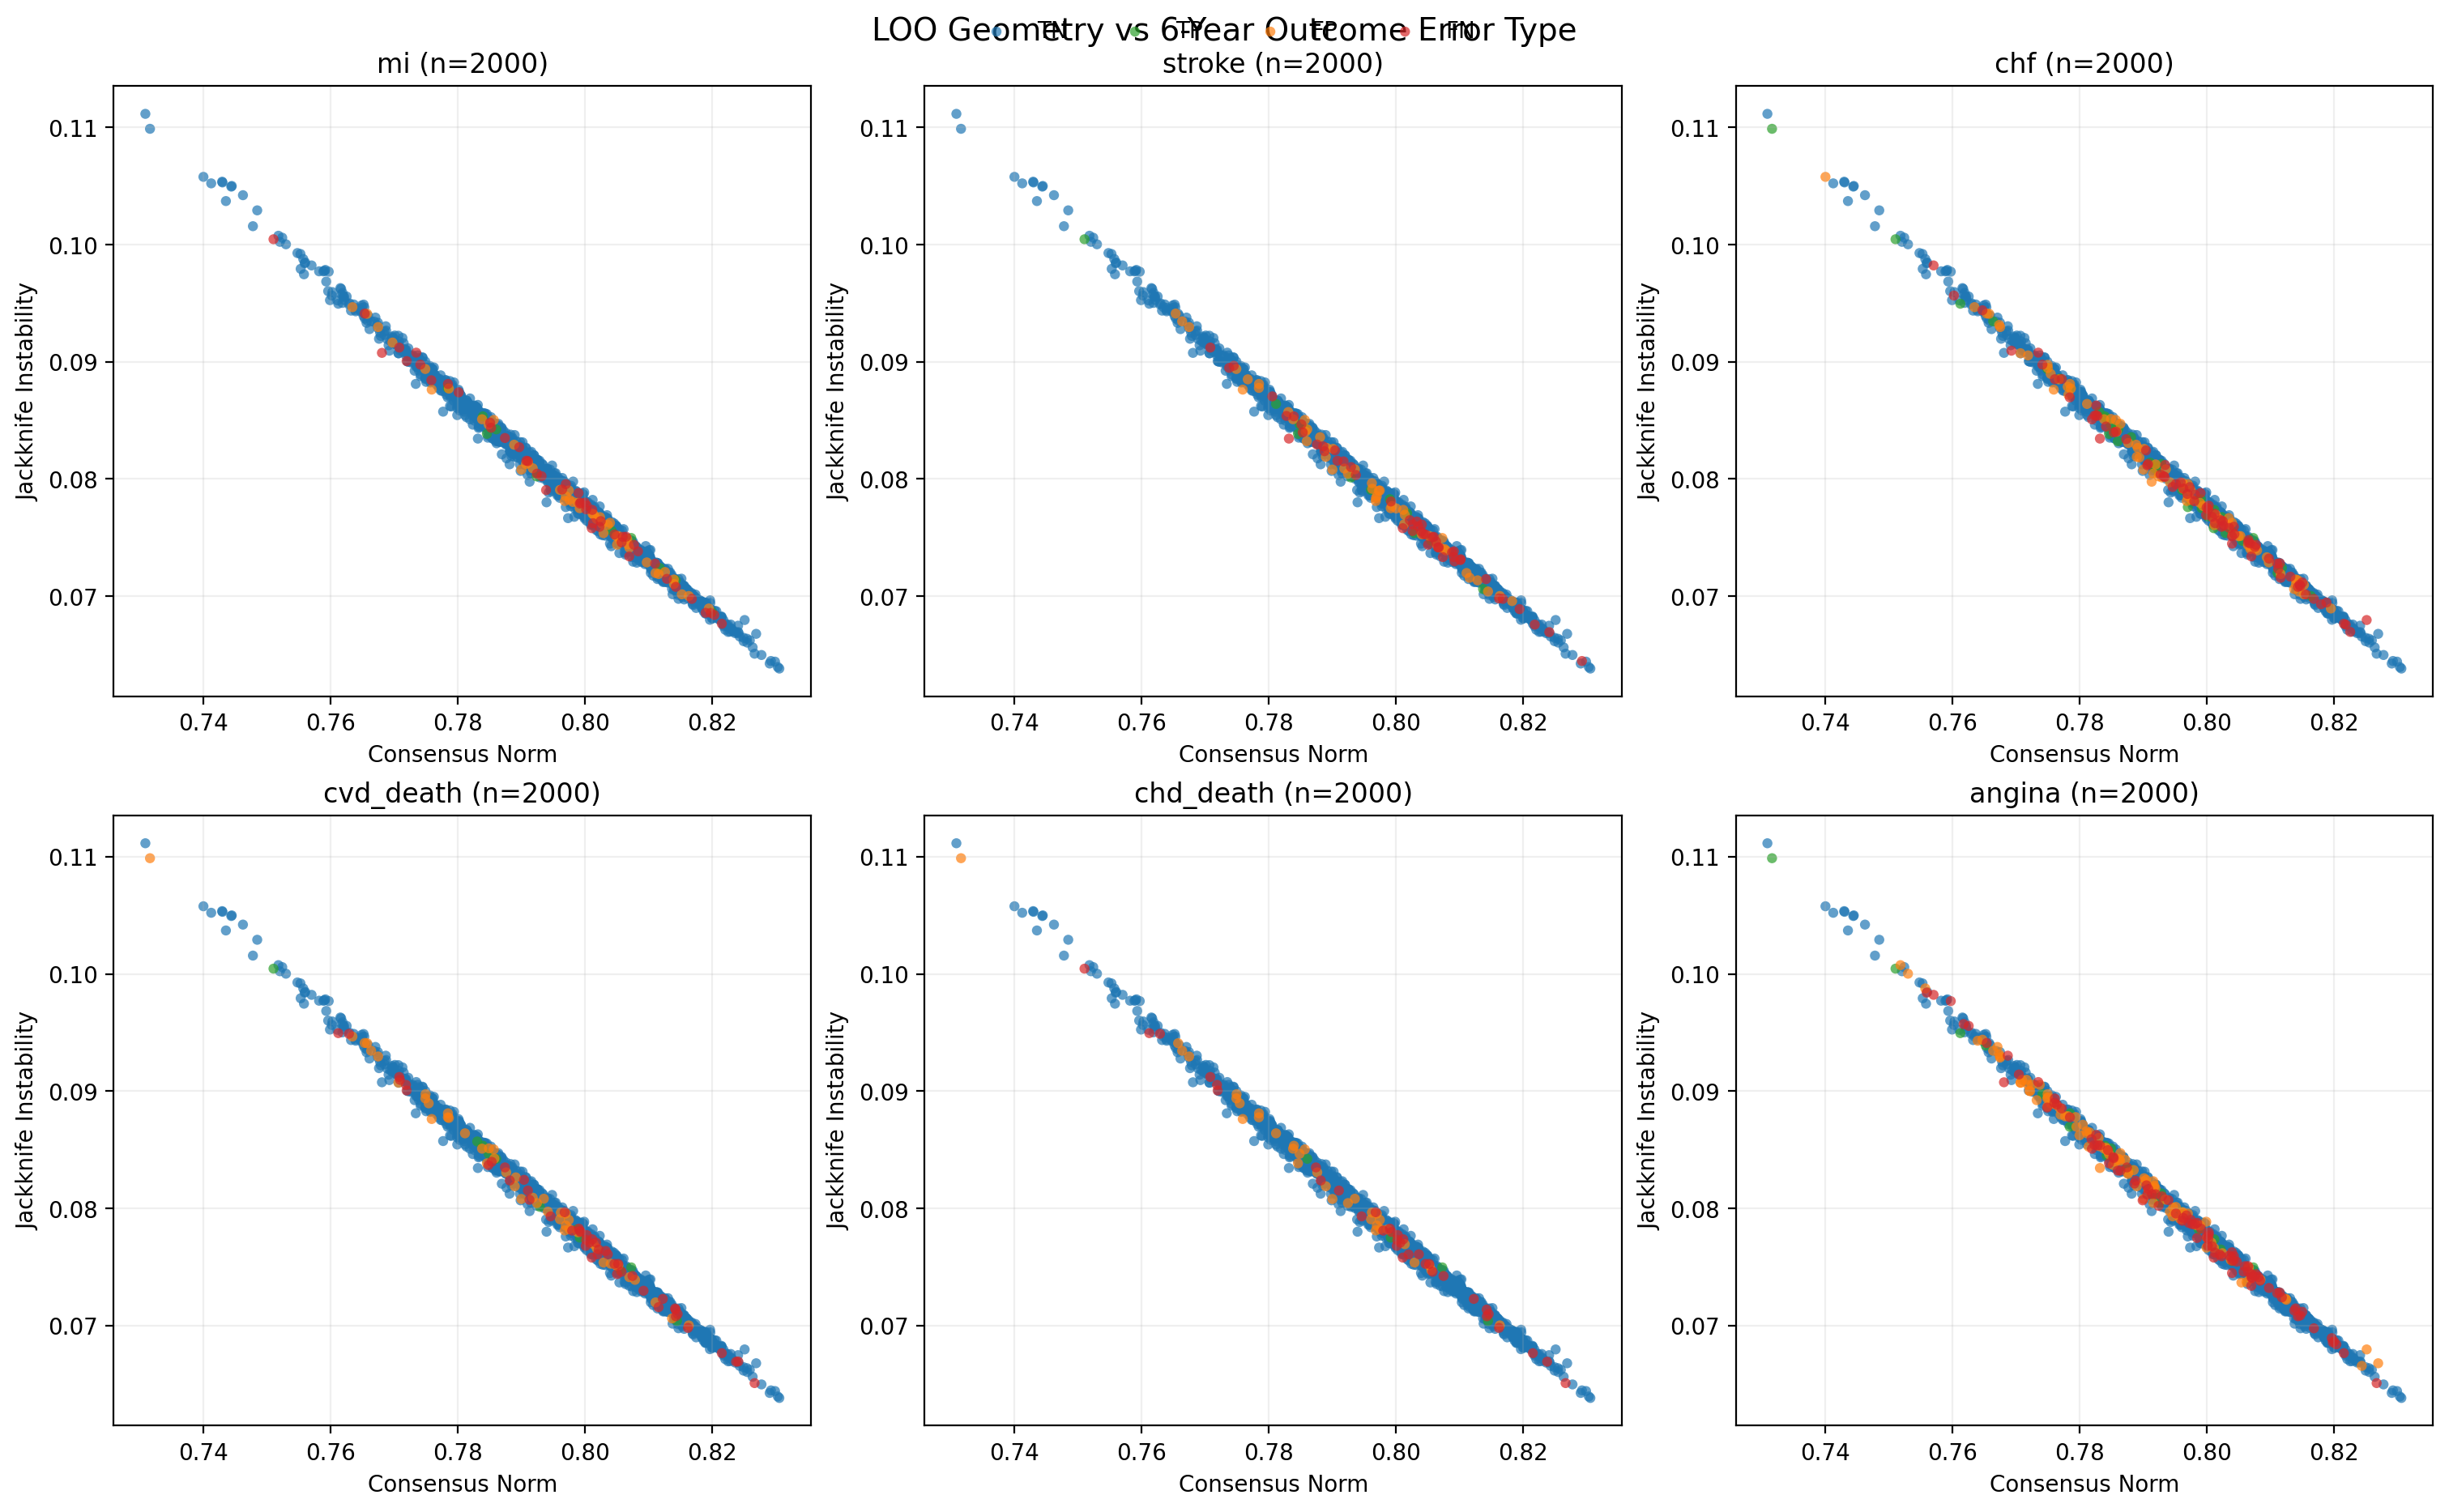

In [8]:
display(Image(filename=str(DIAG_DIR / 'scatter_grid_6y.png')))

이 그림을 보면 `consensus`와 `jackknife`가 거의 1차원 곡선처럼 움직인다. 즉, 지금 정의한 geometry에서는 두 지표가 상당히 강하게 묶여 있다.

따라서 이 scatter는 `geometry tail 존재`를 보여주기에는 좋지만, `error separation` 자체를 강하게 보여주지는 못한다.

## 6. figure 읽기: CHF risk rank vs instability

`CHF`를 focus target으로 잡아서, `risk percentile`과 `jackknife instability`의 관계를 그린 그림이다.

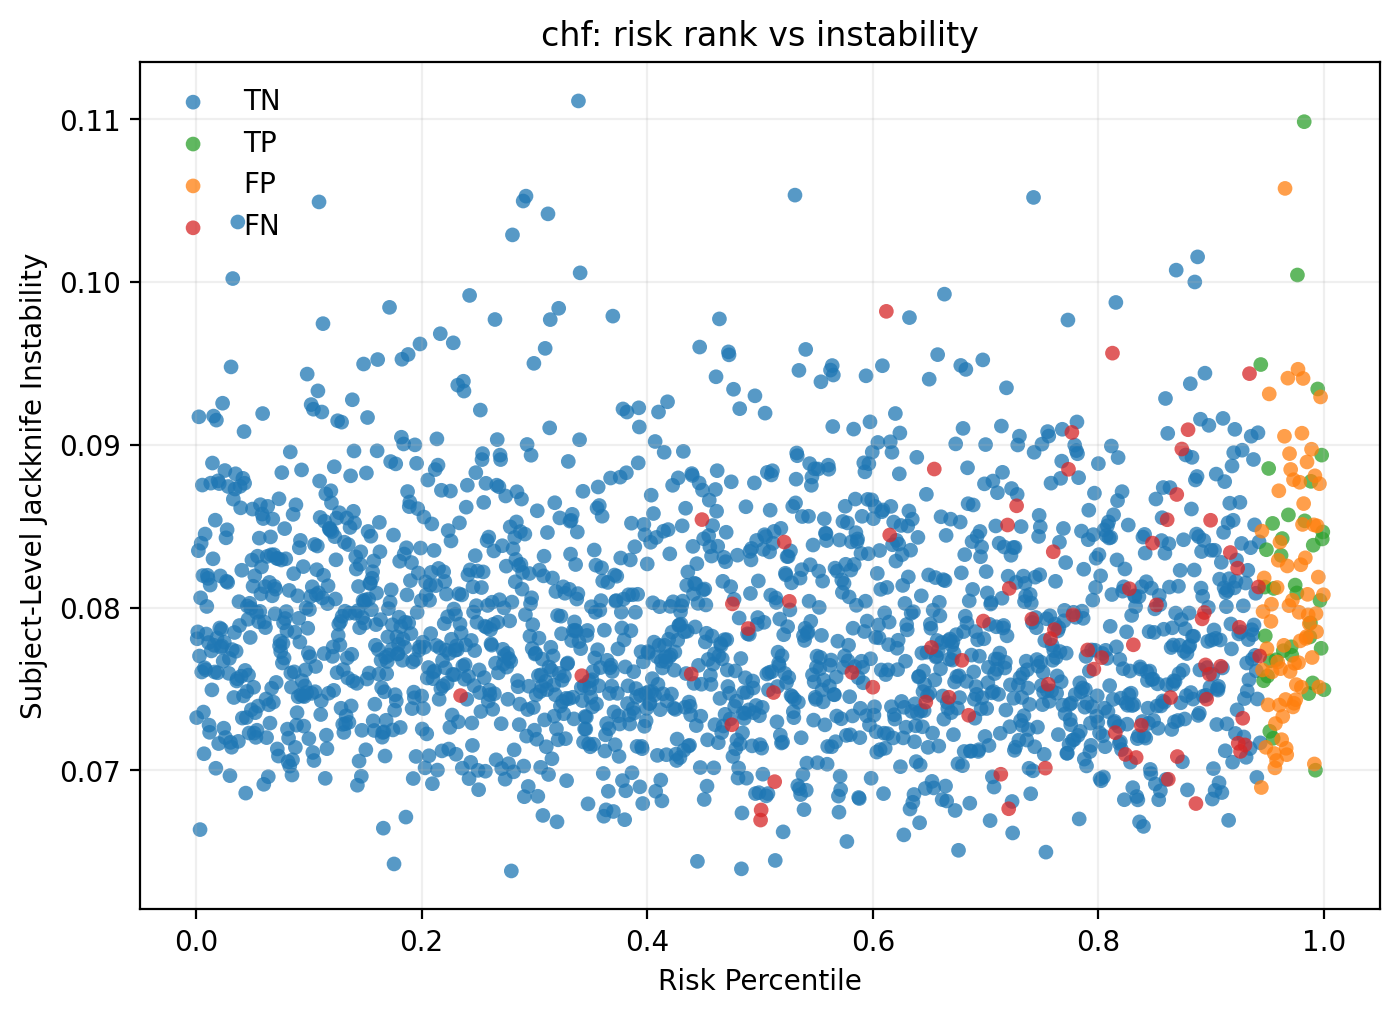

In [9]:
display(Image(filename=str(DIAG_DIR / 'chf_risk_rank_vs_instability_6y.png')))

이 그림에서 봐야 할 포인트는 다음이다.

- model이 높은 risk를 준 subject들 중에서도 instability가 낮은 경우와 높은 경우가 섞여 있다.
- 즉, `높은 risk`와 `높은 instability`가 일대일로 맞물리지는 않는다.
- geometry만으로는 downstream score를 충분히 설명하지 못하고, 아마도 `특정 window의 시간적 위치`나 `event-rich segment` 정보가 더 필요하다는 뜻이다.

## 7. figure 읽기: constellation + pairwise cosine heatmap

아래 그림은 `CHF`에서 대표적인 4개 사례를 뽑은 것이다.

- `stable_tn`: 잘 맞춘 음성 사례 중 가장 안정적인 subject
- `stable_tp`: 잘 맞춘 양성 사례 중 가장 안정적인 subject
- `unstable_fp`: 틀린 양성 예측(FP) 중 가장 불안정한 subject
- `unstable_fn`: 놓친 양성(FN) 중 가장 불안정한 subject

위 패널은 local PCA에서 본 modality 점과 LOO target 방향이고, 아래 패널은 같은 window의 pairwise cosine heatmap이다.

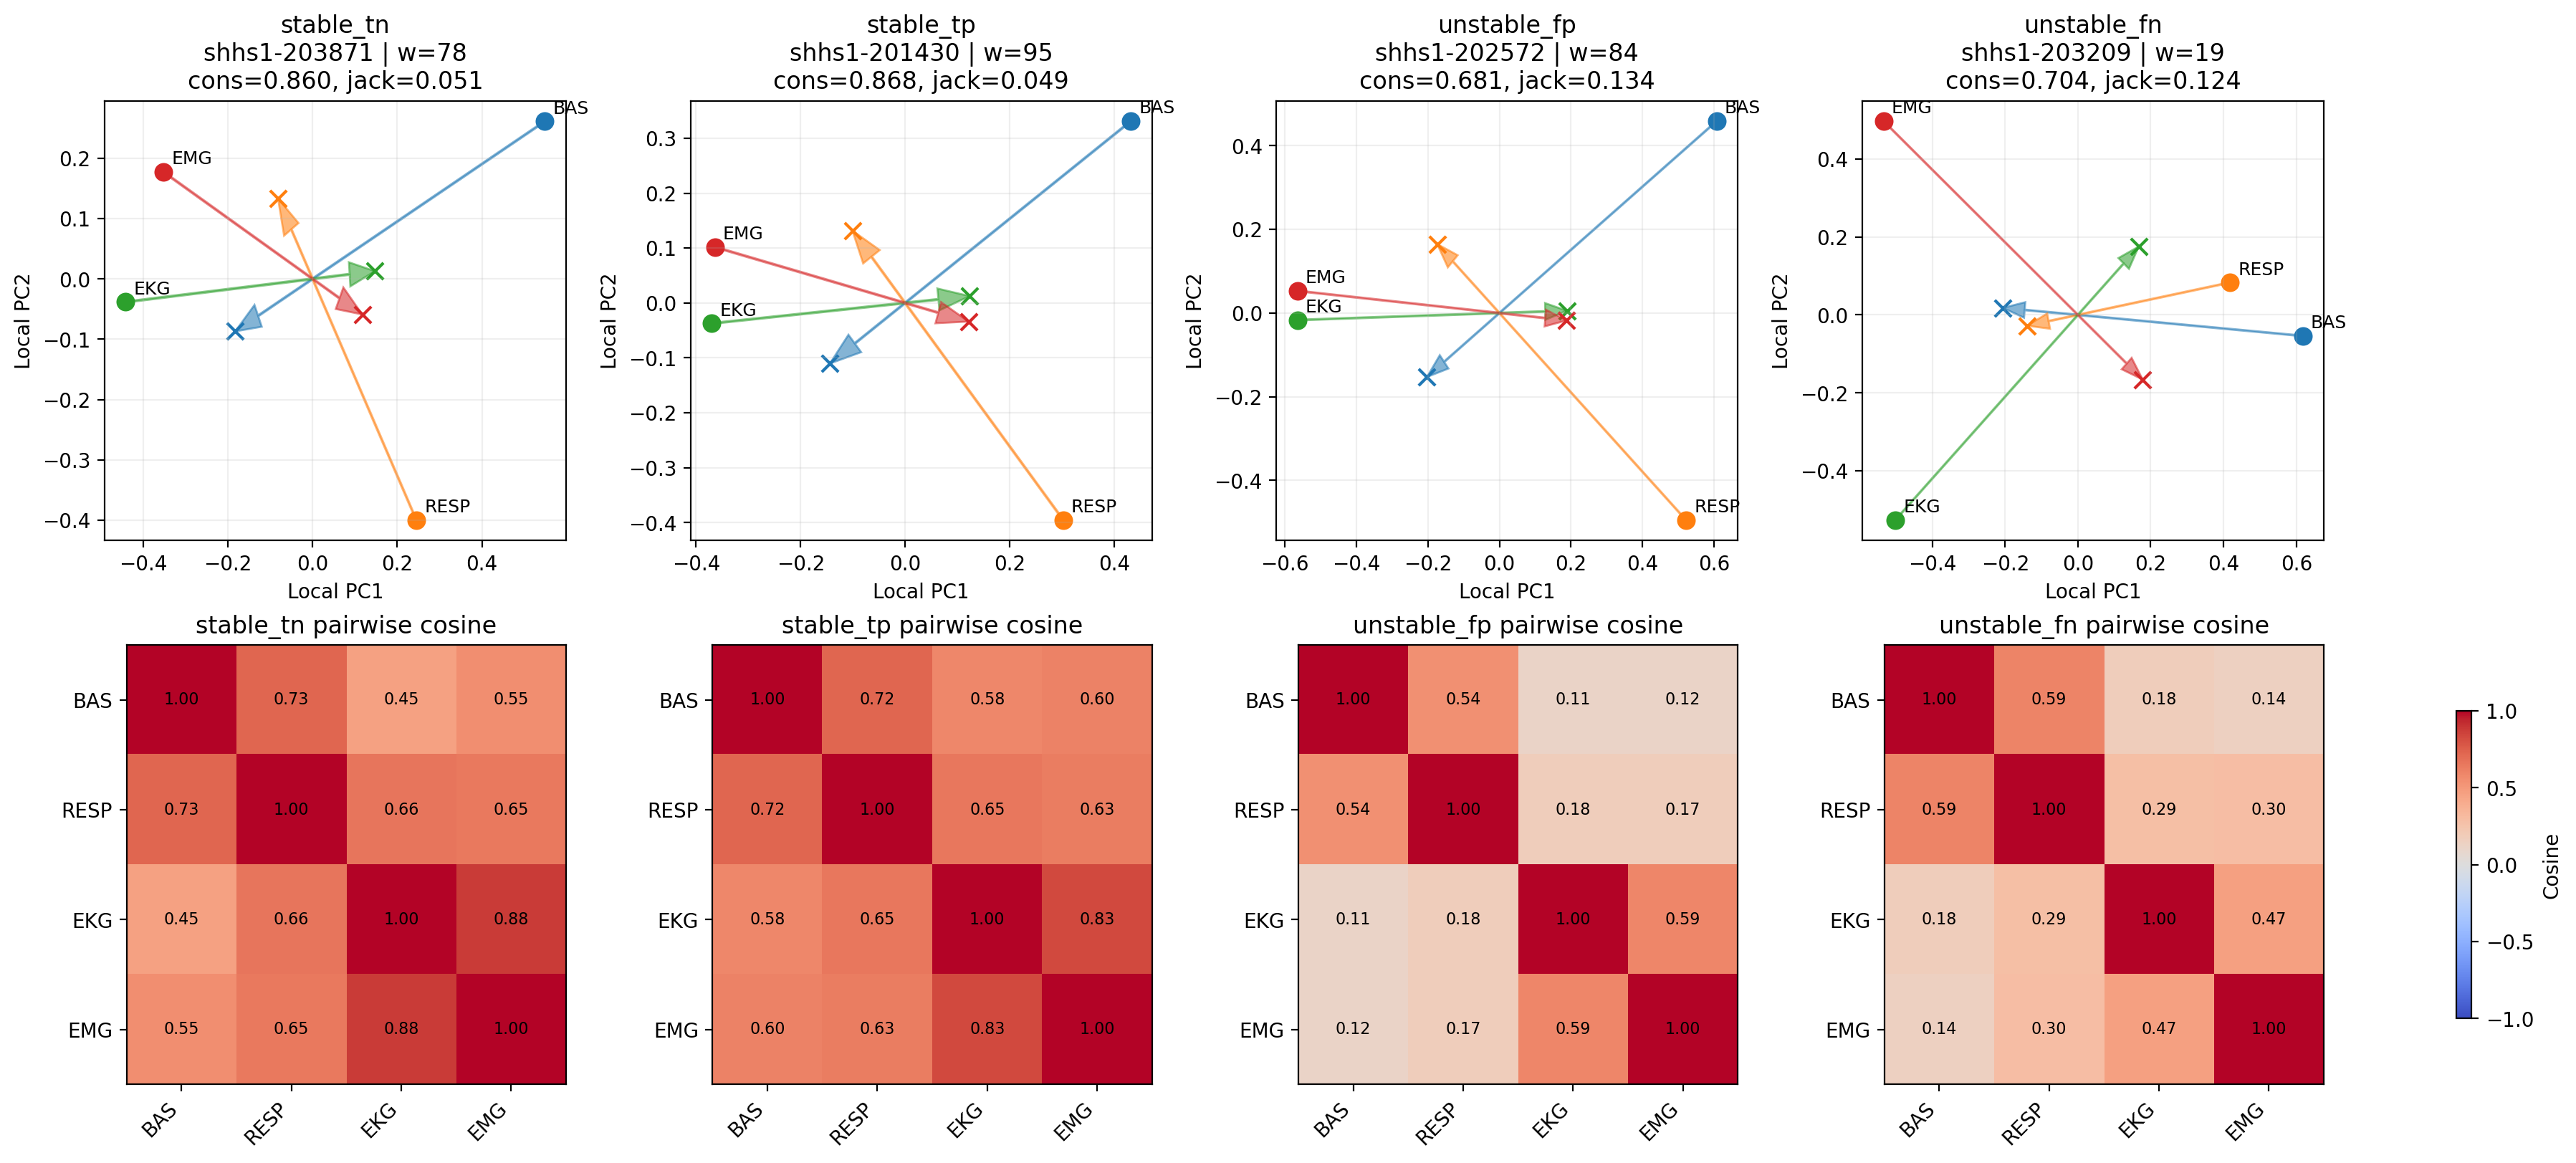

In [10]:
display(Image(filename=str(DIAG_DIR / 'chf_example_constellations.png')))

### constellation figure 해석

이 그림은 현재까지 가장 설명력이 있다.

- `stable_tn`, `stable_tp`는 modality 간 cosine이 전반적으로 높고, query에서 LOO mean으로 가는 화살표도 짧다.
- `unstable_fp`, `unstable_fn`는 특히 `BAS/RESP`와 `EKG/EMG` 사이가 갈라지면서 pairwise cosine이 낮아진다.
- 즉, 네가 계획서에서 적은 `2+2 split`, `modality disagreement`, `compromise target`이 실제 예시 창에서 꽤 유사하게 보인다.

다만 이건 **case study 수준**의 증거다. 전체 subject-level 평균과 바로 연결되는 강한 통계적 효과는 아직 아니다.

## 8. focus target을 테이블로 직접 들여다보기

아래 셀은 `CHF` 기준으로 error type별 대표 사례를 표로 다시 보여준다.

In [11]:
focus = join_df[join_df['target'] == 'chf'].copy()

display(Markdown('### CHF에서 가장 불안정한 FP/FN'))
display(focus[focus['error_type'].isin(['FP', 'FN'])].sort_values('jackknife_instability_mean', ascending=False)[[
    'subject', 'error_type', 'risk', 'risk_rank_pct', 'consensus_norm_mean', 'alignment_mean', 'jackknife_instability_mean'
]].head(10))

display(Markdown('### CHF에서 가장 안정적인 TP/TN'))
display(focus[focus['error_type'].isin(['TP', 'TN'])].sort_values('jackknife_instability_mean', ascending=True)[[
    'subject', 'error_type', 'risk', 'risk_rank_pct', 'consensus_norm_mean', 'alignment_mean', 'jackknife_instability_mean'
]].head(10))

### CHF에서 가장 불안정한 FP/FN

,subject,error_type,risk,risk_rank_pct,consensus_norm_mean,alignment_mean,jackknife_instability_mean
4886,shhs1-202572,FP,1.164806,0.9655,0.740054,0.514879,0.105765
5113,shhs1-203209,FN,-0.549782,0.6120,0.757053,0.547912,0.098211
4683,shhs1-201921,FN,0.273326,0.8125,0.760244,0.554737,0.095643
4539,shhs1-201512,FP,1.319586,0.9770,0.763475,0.560485,0.094653
4547,shhs1-201531,FN,0.923724,0.9340,0.764729,0.562543,0.094384
4847,shhs1-202456,FP,1.188639,0.9680,0.765402,0.564436,0.094106
4850,shhs1-202464,FP,1.409540,0.9815,0.765784,0.564926,0.094087
4822,shhs1-202381,FP,1.053595,0.9515,0.767368,0.568018,0.093138
4665,shhs1-201871,FP,1.991199,0.9970,0.767515,0.568629,0.092952
4507,shhs1-201420,FN,0.568323,0.8795,0.769285,0.573694,0.090938


### CHF에서 가장 안정적인 TP/TN

,subject,error_type,risk,risk_rank_pct,consensus_norm_mean,alignment_mean,jackknife_instability_mean
5352,shhs1-203871,TN,-2.112075,0.2795,0.830584,0.690372,0.063827
5012,shhs1-202911,TN,-1.135735,0.4835,0.830346,0.689707,0.063956
4717,shhs1-202047,TN,-2.816480,0.1755,0.829071,0.687790,0.064256
5937,shhs1-205632,TN,-1.332751,0.4445,0.829908,0.689007,0.064417
5859,shhs1-205388,TN,-0.994246,0.5135,0.829265,0.687717,0.064473
4494,shhs1-201391,TN,0.038423,0.7535,0.827779,0.685243,0.064983
5031,shhs1-202965,TN,-0.264468,0.6760,0.826695,0.682976,0.065095
5253,shhs1-203607,TN,-0.719256,0.5770,0.826387,0.682266,0.065636
5311,shhs1-203762,TN,-0.474662,0.6275,0.825543,0.680662,0.066042
5328,shhs1-203807,TN,-0.066061,0.7240,0.824969,0.679850,0.066160


## 9. 현재까지의 결론 정리

이 노트북 기준으로 지금까지 말할 수 있는 결론은 다음이다.

1. SleepFM의 공개 구현에서 LOO-CL은 실제로 `modality별 normalized 5분 embedding`과 `leave-one-out mean`을 정렬하는 구조다.
2. 전체 SHHS latent space에는 low-consensus / high-instability tail이 실제로 존재한다.
3. representative case에서는 modality split과 compromise target 문제가 눈에 띈다.
4. 하지만 subject-level 평균 geometry만으로는 downstream disease prediction error를 강하게 설명하지 못한다.
5. 따라서 다음 단계는 `window-level temporal context`, `stage transition`, `respiratory/arousal event density`, 또는 `attribution이 높은 window`와 geometry를 직접 연결하는 쪽이 맞다.

즉, 지금 단계는 `LOO-CL geometry audit`까지는 성공적으로 끝냈고, 이제 `why this geometry matters for mistakes`를 시간축 정보와 결합해 더 파고들 차례다.

## 10. 다음 분석을 다시 실행하는 명령

필요하면 아래 명령으로 diagnosis-geometry figure를 다시 만들 수 있다.

In [12]:
rerun_diag_cmd = r"""
python scripts/make_loo_diagnosis_figures.py \
  --geometry-dir artifacts/audit/loo_geometry_model_base_paperexact_shhs \
  --embedding-dir artifacts/embeddings/model_base_paperexact/shhs_5min_agg \
  --eval-dir artifacts/embeddings/model_base_paperexact/DiagnosisFinetuneFullLSTMCOXPHWithDemo_shhs_shhs_6cvd_paperexact_3291_496_2000_demo_labels_BAS_RESP_EKG_EMG__ep_5_bs_8/shhs_downstream_paperlike_3291_496_2000/test \
  --labels-dir artifacts/labels/shhs_6cvd_paperexact_3291_496_2000 \
  --output-dir artifacts/audit/loo_geometry_model_base_paperexact_shhs/diagnosis_6y \
  --focus-target chf
""".strip()

print(rerun_diag_cmd)

python scripts/make_loo_diagnosis_figures.py \
  --geometry-dir artifacts/audit/loo_geometry_model_base_paperexact_shhs \
  --embedding-dir artifacts/embeddings/model_base_paperexact/shhs_5min_agg \
  --eval-dir artifacts/embeddings/model_base_paperexact/DiagnosisFinetuneFullLSTMCOXPHWithDemo_shhs_shhs_6cvd_paperexact_3291_496_2000_demo_labels_BAS_RESP_EKG_EMG__ep_5_bs_8/shhs_downstream_paperlike_3291_496_2000/test \
  --labels-dir artifacts/labels/shhs_6cvd_paperexact_3291_496_2000 \
  --output-dir artifacts/audit/loo_geometry_model_base_paperexact_shhs/diagnosis_6y \
  --focus-target chf
